In [300]:
from torchvision import transforms
from torch.utils.data import DataLoader
import torch
import torch.nn as nn

from astropy.io import fits
import matplotlib.pyplot as plt
import random 
from pathlib import Path
import pandas as pd
pd.set_option('display.max_columns', None)

import sys
import os
parent_dir = os.path.abspath(os.path.join(os.path.dirname('utils.py'), ".."))
sys.path.append(parent_dir)
import utils as ut

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED = 42
RUN = True # Determines if notebook trains model

DEVICE # check device

device(type='cpu')

In [301]:
cwd = Path.cwd()
cutout_dir = cwd.parent / 'data' / 'cutouts'
model_dir = cwd.parent / 'models'

random.seed(SEED)
torch.manual_seed(SEED)

In [302]:
df = pd.DataFrame()

data_paths = []
flags = []
beta = []
av = []

for folder in cutout_dir.iterdir():
    if folder.is_dir():
        data_paths.append(folder)
        header = dict(fits.getheader(folder / 'f150w.fits'))
        flags.append(header['FLAG'])
        beta.append(header['BETA'])

df['FOLDERS'] = data_paths
df['FLAG'] = flags
df['BETA'] = beta

mask = (df['FLAG'] == 1.0)

dfs = {'dusty': df[mask].reset_index(),
       'nodust': df[~mask].reset_index()}

len(dfs['dusty']) + len(dfs['nodust'])

dfs['dusty'].head()

,index,FOLDERS,FLAG,BETA
0,8,c:\Users\harty\Code\Galaxy-Classifier\Summer R...,1.0,2.279
1,9,c:\Users\harty\Code\Galaxy-Classifier\Summer R...,1.0,-0.445
2,10,c:\Users\harty\Code\Galaxy-Classifier\Summer R...,1.0,-0.286
3,18,c:\Users\harty\Code\Galaxy-Classifier\Summer R...,1.0,-0.415
4,19,c:\Users\harty\Code\Galaxy-Classifier\Summer R...,1.0,1.916


In [303]:
train_df = pd.DataFrame()
val_df = pd.DataFrame()

for key in dfs:
    df = dfs[key]
    n_val = int(len(df) * 0.2)

    train_df = pd.concat([df.iloc[n_val:], train_df], ignore_index=True)
    val_df = pd.concat([df.iloc[:n_val], val_df], ignore_index=True)

train_df = train_df.sample(frac=1, random_state=SEED).reset_index(drop=True)
val_df = val_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

len(train_df) + len(val_df)

486

In [304]:
X_train = torch.tensor(train_df['BETA'].values)
X_val = torch.tensor(val_df['BETA'].values)
y_train = torch.tensor(train_df['FLAG'].values)
y_val = torch.tensor(val_df['FLAG'].values)

In [305]:
class FCBlock(nn.Module):
    def __init__(self, input_dim, fc_dim, dropout, num_outputs):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(input_dim, fc_dim),
            nn.BatchNorm1d(fc_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),

            nn.Linear(fc_dim, fc_dim // 2),
            nn.BatchNorm1d(fc_dim // 2),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),

            nn.Linear(fc_dim // 2, num_outputs))

    def forward(self, x):
        return self.block(x)

In [306]:
class GalaxyClassifier(nn.Module):
    "Full Galaxy Classifier network. Combines the ConvBlock, ConvTokenizer, CvTBlock, and add a FCBlock"
    "Add softmax to appropriate outputs and scales all outputs between zero and one"
    def __init__(
        self,
        num_outputs: int = 1,
        input_dim: int = 8,
        fc_dim: int = 128,
        dropout: float = 0.4,
        **kwargs):

        super().__init__()
        self.fc = FCBlock(input_dim, fc_dim, dropout, num_outputs)

    def forward(self, x):
        x = self.fc(x)

        return x

In [307]:
params = {'num_outputs': 2,
          'input_dim': 1,
          'fc_dim': 128,
          'dropout': 0.6}

In [308]:
LR = 1e-4
WD = 1e-2

# RMSE was used in original challenge, so I use MSE and take the
# square root of it during training
weights = torch.tensor([1.0, 2.0]).to(DEVICE)
loss_func = torch.nn.CrossEntropyLoss(weight=weights)

train_losses = []
val_losses = []

In [309]:
model = GalaxyClassifier(**params).to(DEVICE) 
optimizer = torch.optim.AdamW(model.parameters(), lr = LR, weight_decay=WD)

model_path = None
if model_path is not None:
        checkpoint = torch.load(model_path, map_location=DEVICE, weights_only=False)

        # 3. Restore the states
        model.load_state_dict(checkpoint['model_state_dict'])

        # 4. Restore metadata variables
        start_epoch = checkpoint['epoch']
        train_losses = checkpoint['train_losses']
        val_losses = checkpoint['val_losses']
else:
        start_epoch = 1
        train_losses = []
        val_losses = []

In [310]:
# 4 'dummy' images to test if model takes and gives inputs / outputs
# of correct shape without crashing
dummy = torch.randn(8, 1).to(DEVICE)
out = model(dummy)
print(f"Output shape: {out.shape}") # expect [4, 1]
# calculate number of model parameters
print(f"Params: {sum(p.numel() for p in model.parameters()):,}") 

Output shape: torch.Size([8, 2])
Params: 9,026


In [311]:
from torch.utils.data import Subset

# sets the number of galaxies used in training
train_size = len(X_train)
val_size = len(X_val)

BATCH_SIZE = 32
EPOCHS = 512

# get subsets of training and validation data based on num batches and batchsize
train_subset = Subset(X_train, range(train_size))
val_subset = Subset(X_val, range(val_size))

# set up minibatches
train_data = torch.utils.data.TensorDataset(X_train, y_train)
train_loader = torch.utils.data.DataLoader(train_data,
                                           batch_size=BATCH_SIZE,
                                           shuffle=True)

val_data = torch.utils.data.TensorDataset(X_val, y_val)
val_loader = torch.utils.data.DataLoader(val_data,
                                           batch_size=BATCH_SIZE,
                                           shuffle=True)

In [312]:
from tqdm.auto import tqdm, trange

if RUN == True:
    # Training Loop ---------------------------------------------------------------------------------------
    for epoch in trange(EPOCHS, desc="Epochs", smoothing=0, ):
        model.train()
        running_loss = 0
        num_done = 0

        for data, labels in train_loader:
            optimizer.zero_grad()
            if data.ndim == 1:
                data = data.unsqueeze(1)
            data = data.float()
            outputs = model(data)
            labels = labels.long() # FOR CLASSIFICATION 
            loss = loss_func(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * data.size(0)
            num_done += data.size(0)
            running_avg_loss = (running_loss / num_done) ** 0.5

        train_losses.append(running_avg_loss) # track loss only once per epoch

        # Compute Validation Accuracy ----------------------------------------------------------------------
        model.eval()
        running_loss = 0
        num_done = 0

        with torch.no_grad():
            for data, labels in val_loader:
                if data.ndim == 1:
                    data = data.unsqueeze(1)
                data = data.float()
                
                outputs = model(data)
                labels = labels.long()
                loss = loss_func(outputs, labels)

                running_loss += loss.item() * data.size(0)
                num_done += data.size(0)

                running_avg_val_loss = (running_loss / num_done) ** 0.5
                
            val_losses.append(running_avg_val_loss)



Epochs:   0%|          | 0/512 [00:00<?, ?it/s]

In [313]:
if RUN: 
    model.eval()

    corr = 0
    tot = 0

    with torch.no_grad():
        for data, labels in val_loader:
            labels = labels.long()
            if data.ndim == 1:
                data = data.unsqueeze(1)
            data = data.float()
            outputs = model(data)

            tot += data.size(0)
            predictions = torch.argmax(outputs, dim=1)
            corr += (predictions == labels).float().sum()
            
    print(corr / tot)

tensor(0.6667)


In [318]:
predictions - labels

tensor([-1,  0,  0,  0,  1,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,
        -1,  0,  0, -1,  0, -1,  0,  0, -1,  0, -1,  0,  0,  0])

In [314]:
if RUN:
    # save the model along with loss curve data so I can test different parameters and keep the best one
    # format: model_{RMSE}.pth
    torch.save({'epoch': EPOCHS + start_epoch,
                'model_state_dict': model.state_dict(),
                'train_losses': train_losses,
                'optimizer_state_dict': optimizer.state_dict(),
                'val_losses': val_losses},
                model_dir / 'fc' / f"model_{val_losses[-1]:.3f}.pth")

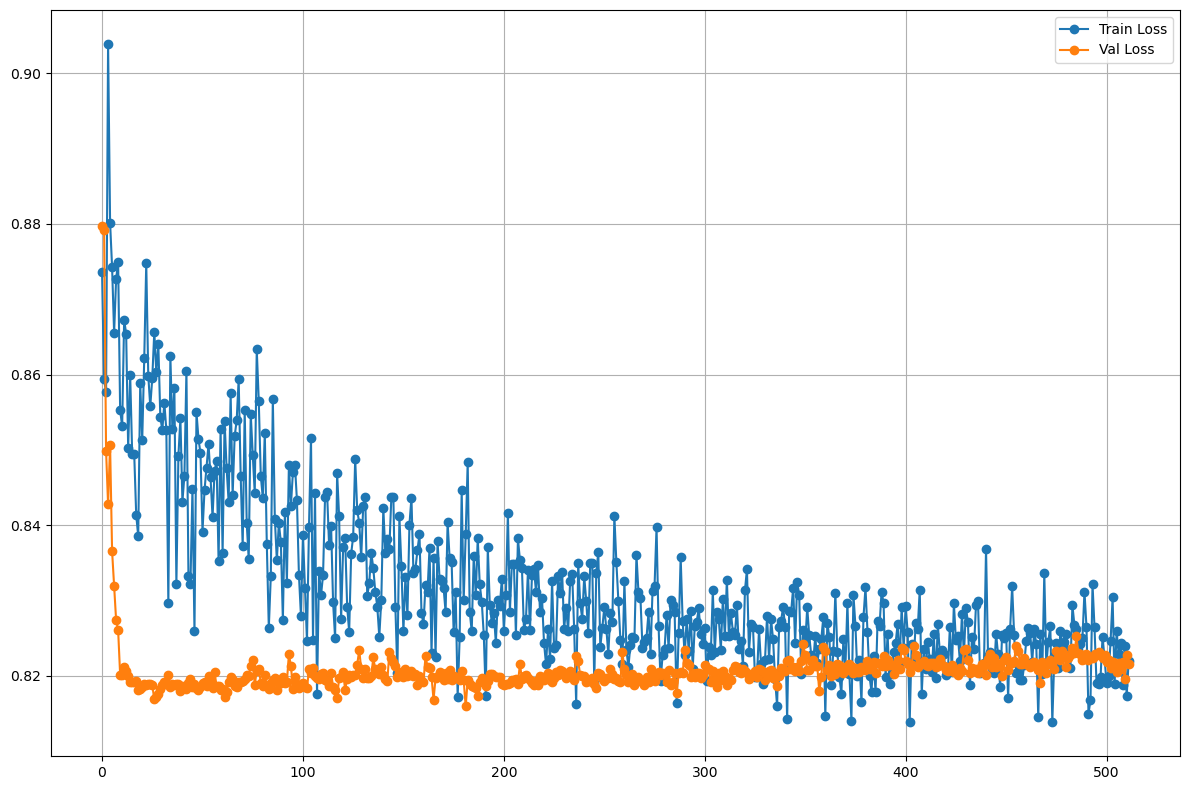

In [315]:
fig, ax = plt.subplots(figsize=(12,8))
ax.plot(train_losses, label="Train Loss", marker='o')
ax.plot(val_losses, label="Val Loss", marker='o')
ax.grid()
ax.legend()
fig.tight_layout()

In [316]:
eval = False

if eval:
    model_path = r"C:\Users\harty\Code\Galaxy-Classifier\Summer Research\models\regression\model_3.363.pth" # new model path 

    params = {'in_channels': 3,
            'num_outputs': 1,
            'conv_channels': 8,
            'embed_dim': 32,
            'num_heads': 2,
            'num_cvt_layers': 1,
            'fc_dim': 32,
            'dropout': 0.4}

    model = GalaxyClassifier(**params).to(DEVICE) # untrained model with same dimensions as the one in model_path

    checkpoint = torch.load(model_path, map_location=DEVICE, weights_only=False)

    # get losses and model from file
    model.load_state_dict(checkpoint['model_state_dict'])
    train_losses = checkpoint['train_losses']
    val_losses = checkpoint['val_losses']

    model.eval()

    corr = 0
    tot = 0

    with torch.no_grad():
        for imgs, labels in val_loader:
            outputs = model(imgs)
            print(outputs.std(), outputs.max())

            tot += imgs.size(0)
            corr += sum(1 for x, y in zip(labels, outputs) if x >= 15 and y >= 15)
            corr += sum(1 for x, y in zip(labels, outputs) if x < 15 and y < 15)
            
    corr / tot